In [1]:
from myutils import *
from src import *

In [4]:
width = 8.5 / 2.54 #inches

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath, amssymb, physics, microtype}'

formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((0, 0))

spade_params = {
    'marker': 'o',
    'edgecolors': 'tab:blue',
    'facecolors': 'none',
    's': 7,
    'linewidths': 0.5
}

di_params = {
    'marker': '+',
    'facecolor': 'k',
    's': 9,
    'linewidths': 0.5
}

c_red = 'tab:orange'
# c_red = 'r'

In [6]:
@cache
def run_sim_fig4():
    sim = Simulator('hg', DMD.A(5), 0.2)

    hg_mean, hg_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('pm', DMD.A(5), 0.2)

    pm_mean, pm_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*60, 60)
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.photons * c.estimates.var(0, ddof=1))

    sim = Simulator('di', DMD.A(5), 0.2)

    di_mean, di_var = [], []
    for b_prime in np.linspace(0, 0.1, 30):
        c = sim.gen(b_prime*400, 400)
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.photons * c.estimates.var(0, ddof=1))

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars


In [7]:
means, vars = run_sim_fig4()

cache hit: reading result from cache file


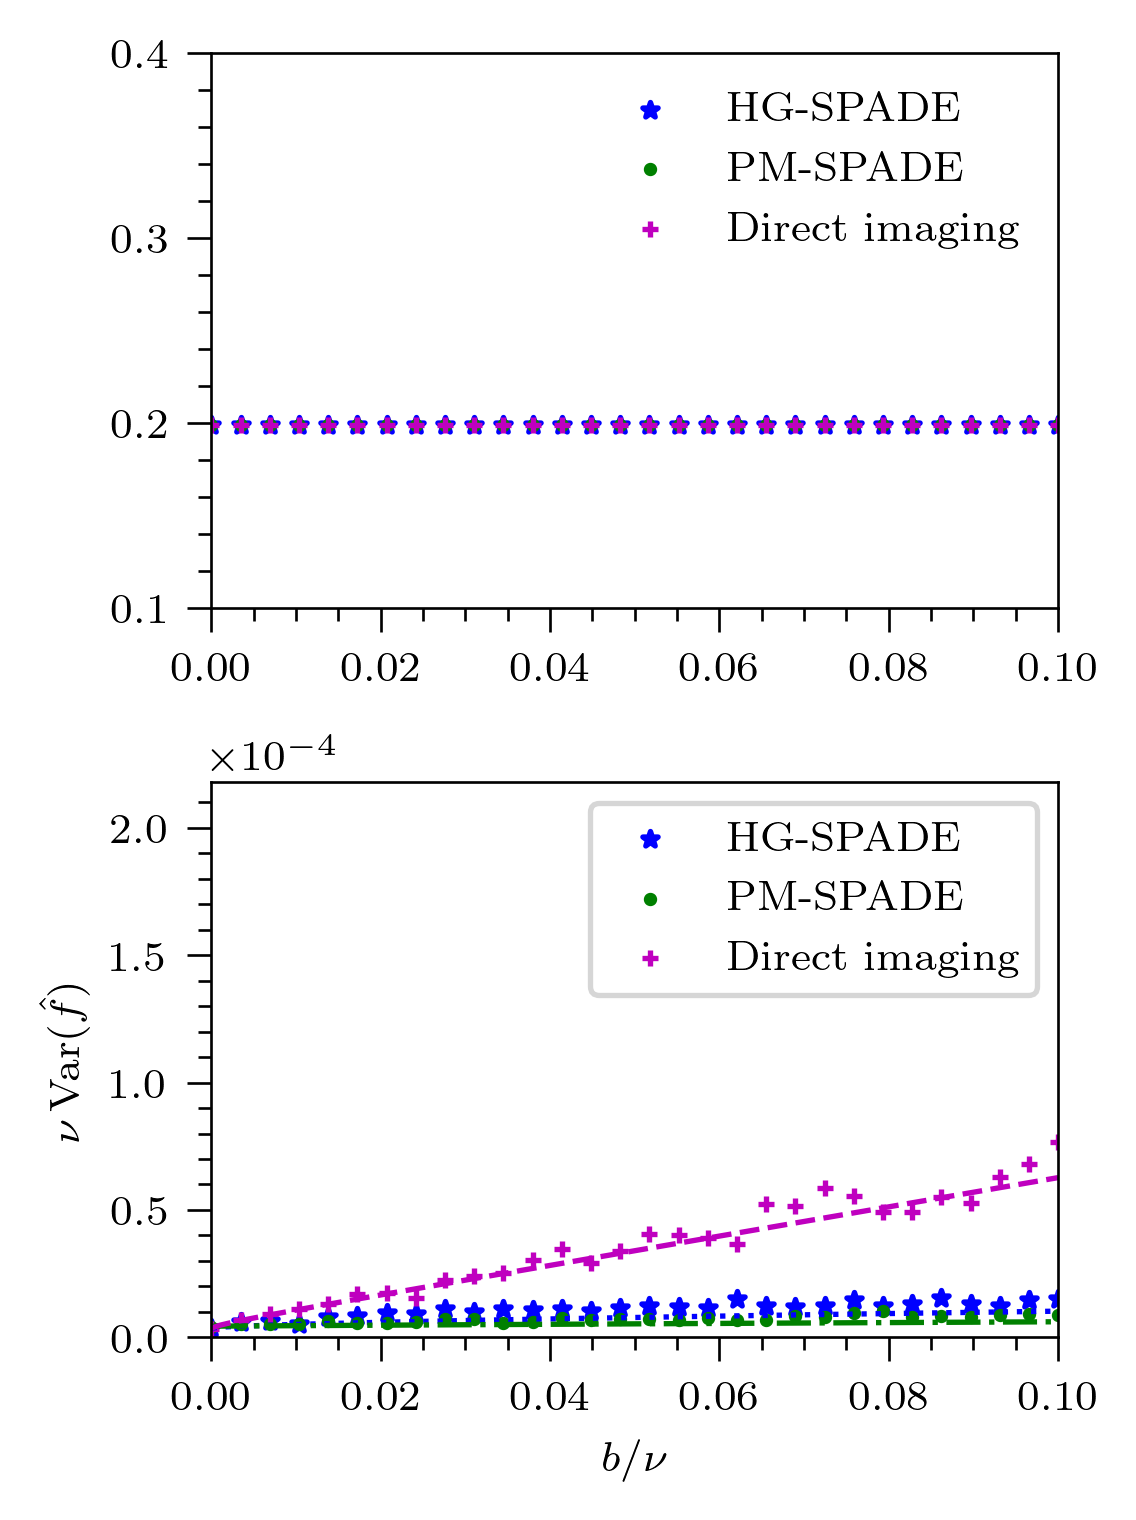

In [9]:
plt.rcParams['figure.figsize'] = (3, 4)

plt.subplot(2, 1, 1) 

plt.scatter(np.linspace(0, 0.1, 30), np.array(means[0]), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[1]), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), np.array(means[2]), marker='+', color='m', label=r'Direct imaging')

plt.legend(frameon=False)
plt.xlim(0, 0.1)
plt.ylim(0.1, 0.4)

plt.subplot(2, 1, 2)

plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[0]), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[1]), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0, 0.1, 30), np.array(vars[2]), marker='+', color='m', label=r'Direct imaging')

plt.plot(np.linspace(0, 0.1, 100), 1/HG_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'b:')
plt.plot(np.linspace(0, 0.1, 100), 1/PM_SPADE.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'g-.')
plt.plot(np.linspace(0, 0.1, 100), 1/DI.CFI(np.linspace(0, 0.1, 100), (4/pi) * DMD.A(5), 0.2), 'm--')

plt.xlabel(r'$b/\nu$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
plt.legend()
plt.xlim(0, 0.1)
plt.ylim(0, 2.18e-4)

plt.gca().yaxis.set_major_formatter(formatter)
plt.tight_layout()
plt.show()

In [13]:
@cache
def run_sim_fig3():
    hg_mean, hg_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('hg', DMD.A(5), f).gen()
        c.est()
        hg_mean.append(c.estimates.mean())
        hg_var.append(c.estimates.var() * c.photons)


    pm_mean, pm_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('pm', DMD.A(5), f).gen()
        c.est()
        pm_mean.append(c.estimates.mean())
        pm_var.append(c.estimates.var() * c.photons)


    di_mean, di_var = [], []
    for f in np.linspace(0.1, 0.4, 61):
        c = Simulator('di', DMD.A(5), f).gen()
        c.est()
        di_mean.append(c.estimates.mean())
        di_var.append(c.estimates.var() * c.photons)

    means = [hg_mean, pm_mean, di_mean]
    vars = [hg_var, pm_var, di_var]
    return means, vars

In [14]:
means, vars = run_sim_fig3()

cache hit: reading result from cache file


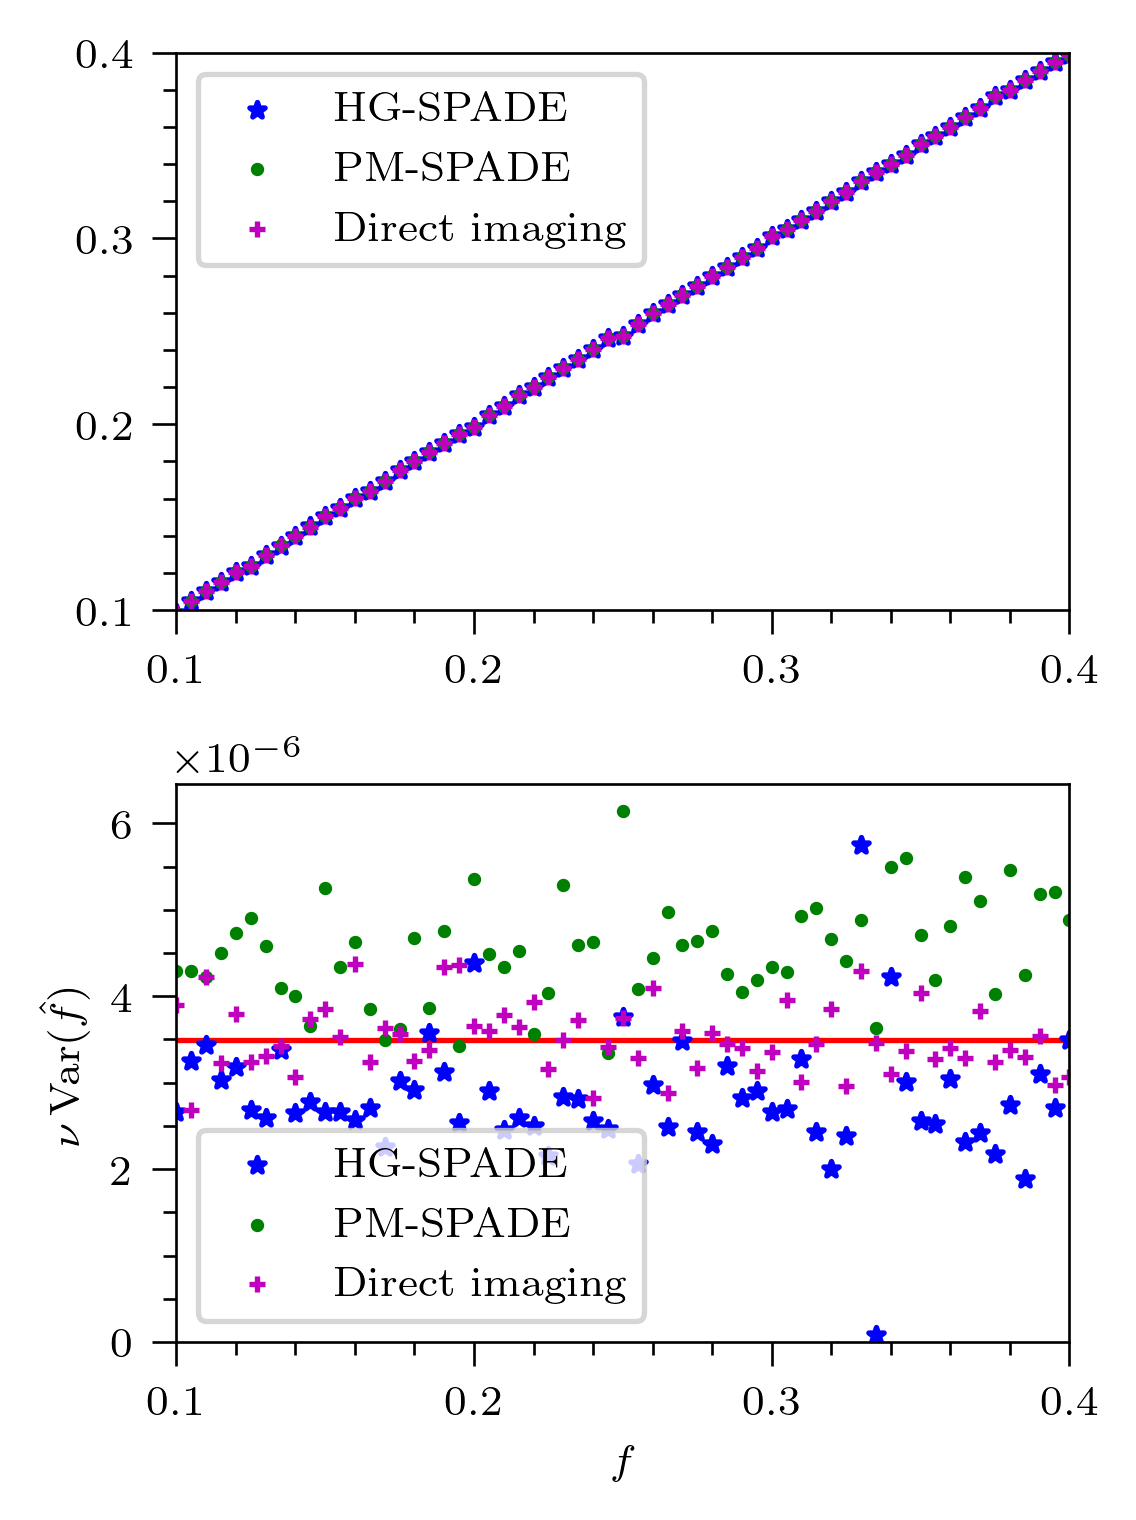

In [15]:
plt.rcParams['figure.figsize'] = (3, 4)

plt.subplot(2, 1, 1)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[0]), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[1]), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(means[2]), marker='+', color='m', label=r'Direct imaging')

plt.legend(frameon=True)
plt.xlim(0.1, 0.4)
plt.ylim(0.1, 0.4)

plt.subplot(2, 1, 2)

plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[0]), marker='*', color='b', label=r'HG-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[1]), marker='.', color='g', label=r'PM-SPADE')
plt.scatter(np.linspace(0.1, 0.4, 61), np.array(vars[2]), marker='+', color='m', label=r'Direct imaging')

plt.axhline(1/DI.ApproxCFI((4/pi) * DMD.A(5)), color='red', zorder=0)
plt.xlim(0.1, 0.4)
plt.ylim(0, None)

plt.xlabel(r'$f$')
plt.ylabel(r'$\nu \operatorname{Var}(\hat f)$')
# plt.title(r'$A=0.47\sigma$')
plt.legend(frameon=True)

plt.tight_layout()
plt.show()